Example code to recreate Fig. 10 (distributions of the log-distance ratio and uncertainty) in the DR1 TF paper

In [1]:
from astropy.io import fits

import numpy as np

import matplotlib.pyplot as plt

# Data

In [2]:
hdul = fits.open('fig10_data.fits')

eta = hdul['ETA'].data
eta_err = hdul['ETA_ERR'].data

hdul.close()

In [3]:
# Recreate bin edges
eta_bins = np.zeros(len(eta['BIN_EDGE']) + 1)
eta_bins[:-1] = eta['BIN_EDGE']
eta_bins[-1] = eta['BIN_EDGE'][-1] + (eta['BIN_EDGE'][1] - eta['BIN_EDGE'][0])

sigma_bins = np.zeros(len(eta_err['BIN_EDGE']) + 1)
sigma_bins[:-1] = eta_err['BIN_EDGE']
sigma_bins[-1] = eta_err['BIN_EDGE'][-1] + (eta_err['BIN_EDGE'][1] - eta_err['BIN_EDGE'][0])

# Plot

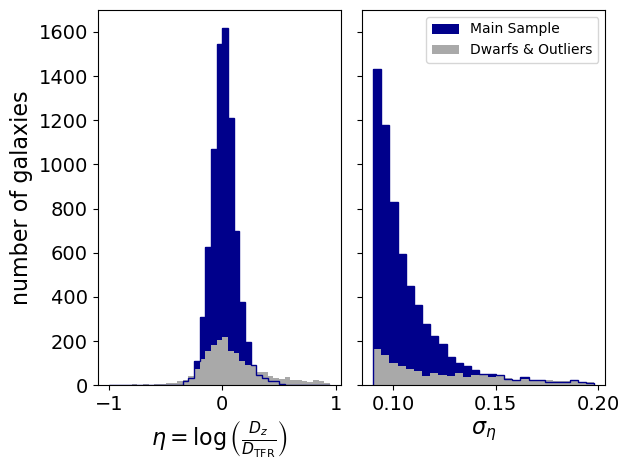

In [4]:
plt.figure(tight_layout=True)

#-------------------------------------------------------------------------------
# Histogram of the log-distance ratio
#-------------------------------------------------------------------------------
ax = plt.subplot(121)

plt.hist(eta['BIN_EDGE'], eta_bins, weights=eta['N_MAIN'], color='darkblue')
plt.hist(eta['BIN_EDGE'], eta_bins, weights=eta['N_DWARF'], color='darkgray')
plt.hist(eta['BIN_EDGE'], eta_bins, weights=eta['N_MAIN'], histtype='step', color='darkblue')

plt.ylabel('number of galaxies', fontsize=16)
plt.xlabel(r'$\eta = \log \left( \frac{D_z}{D_{\text{TFR}}} \right)$', 
	       fontsize=16)

plt.tick_params(axis='both', which='major', labelsize=14)
#-------------------------------------------------------------------------------
# Histogram of the uncertainties in the log-distance ratio
#-------------------------------------------------------------------------------
ax2 = plt.subplot(122, sharey=ax)

plt.hist(eta_err['BIN_EDGE'], sigma_bins, weights=eta_err['N_MAIN'], 
         color='darkblue', 
         label='Main Sample')
plt.hist(eta_err['BIN_EDGE'], sigma_bins, weights=eta_err['N_DWARF'], 
         color='darkgray', 
         label='Dwarfs & Outliers')
plt.hist(eta_err['BIN_EDGE'], sigma_bins, weights=eta_err['N_MAIN'], 
         histtype='step',
         color='darkblue')

plt.legend()

plt.xlabel(r'$\sigma_{\eta}$', fontsize=16)

ax2.tick_params(axis='y', labelleft=False)
plt.tick_params(axis='x', which='major', labelsize=14);